# Notebook 4 — MLP 


**Flow 2 tầng:**
- Tầng 1: So sánh các kiến trúc bằng **val set** → chọn kiến trúc tốt nhất theo **Validation PR-AUC**
- Threshold được chọn trên validation bằng cùng rule với notebook Logistic Regression
- Tầng 2: Đánh giá kiến trúc tốt nhất trên **test set đúng 1 lần** → lưu `y_prob` vào `features/` cho Member A


## 1. Import thư viện

In [30]:
import json
import os
from pathlib import Path

import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import warnings
from keras import callbacks, layers, regularizers
from sklearn.metrics import precision_recall_curve, roc_curve

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
from credit_utils.utils import load_creditcard_csv, preprocess_credit_card_data, apply_smote, select_threshold_from_pr_curve

from credit_utils.utils import (
    load_creditcard_csv,
    preprocess_credit_card_data,
    apply_smote,
    select_threshold_from_pr_curve,
)

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.19.0


## 2. Preprocessing

In [31]:
# Load data và preprocessing ban đầu
df = load_creditcard_csv()
X_train, X_val, X_test, y_train, y_val, y_test = preprocess_credit_card_data(df)

input_dim = X_train.shape[1]

1. Tách Features (X) và Target (y)...
2. Chia tập Train+Val / Test (80/20) với Stratify...
3. Chia tập Train / Val (70/10) với Stratify...
4. Áp dụng RobustScaler cho Time và Amount (fit trên train)...

Kích thước các tập:
  Train : (199364, 30) | Fraud rate: 0.173%
  Val   : (28481, 30)   | Fraud rate: 0.172%
  Test  : (56962, 30)  | Fraud rate: 0.172%


## 3. Định nghĩa kiến trúc Neural Network

In [32]:
def build_model(input_dim, architecture='standard'):
    """
    3 kiến trúc để so sánh nội bộ:
    - standard : 3 hidden layers (128→64→32)  — baseline DL
    - deep     : 4 hidden layers (256→128→64→32) — sâu hơn
    - wide     : 3 hidden layers (256→128→64)  — rộng hơn

    Thiết kế chung:
    - Funnel shape: ép model học biểu diễn compact dần
    - BatchNormalization: ổn định gradient
    - Dropout giảm nhẹ: model không overfit thực sự với val set đúng
    - L2: phạt weight lớn
    - Sigmoid output: xác suất fraud ∈ (0, 1)
    """
    if architecture == 'standard':
        model = keras.Sequential([
            layers.Input(shape=(input_dim,)),

            layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4)),
            layers.BatchNormalization(),
            layers.Activation('relu'),
            layers.Dropout(0.2),

            layers.Dense(64, kernel_regularizer=regularizers.l2(1e-4)),
            layers.BatchNormalization(),
            layers.Activation('relu'),
            layers.Dropout(0.2),

            layers.Dense(32, kernel_regularizer=regularizers.l2(1e-4)),
            layers.BatchNormalization(),
            layers.Activation('relu'),
            layers.Dropout(0.1),

            layers.Dense(1, activation='sigmoid')
        ], name='standard_mlp')

    elif architecture == 'deep':
        inputs = layers.Input(shape=(input_dim,))
        x = layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4))(inputs)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.Dropout(0.3)(x)

        x = layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.Dropout(0.2)(x)

        x = layers.Dense(64, kernel_regularizer=regularizers.l2(1e-4))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.Dropout(0.2)(x)

        x = layers.Dense(32, kernel_regularizer=regularizers.l2(1e-4))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.Dropout(0.1)(x)

        outputs = layers.Dense(1, activation='sigmoid')(x)
        model = keras.Model(inputs, outputs, name='deep_mlp')

    elif architecture == 'wide':
        model = keras.Sequential([
            layers.Input(shape=(input_dim,)),

            layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4)),
            layers.BatchNormalization(),
            layers.Activation('relu'),
            layers.Dropout(0.3),

            layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4)),
            layers.BatchNormalization(),
            layers.Activation('relu'),
            layers.Dropout(0.2),

            layers.Dense(64, kernel_regularizer=regularizers.l2(1e-4)),
            layers.BatchNormalization(),
            layers.Activation('relu'),
            layers.Dropout(0.1),

            layers.Dense(1, activation='sigmoid')
        ], name='wide_mlp')

    else:
        raise ValueError(f'Unknown architecture: {architecture}. Chọn: standard, deep, wide')

    return model

## 4. Hàm train

In [33]:
def train_model(model, X_train, y_train, X_val, y_val,
                epochs=100, batch_size=512):

    print(f'\nTraining: {model.name}')
    print(f'Train size: {len(y_train)} | Fraud ratio: {y_train.mean()*100:.2f}%')
    print(f'Val size  : {len(y_val)} | Fraud ratio: {y_val.mean()*100:.3f}%')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=[
            keras.metrics.AUC(name='auc'),
            keras.metrics.AUC(curve='PR', name='pr_auc'),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
        ]
    )

    cb_list = [
        callbacks.EarlyStopping(
            monitor='val_pr_auc', patience=10,
            restore_best_weights=True, mode='max', verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_pr_auc', factor=0.5, patience=5,
            mode='max', min_lr=1e-6, verbose=1
        ),
        callbacks.ModelCheckpoint(
            f'../models/best_{model.name}.keras',
            monitor='val_pr_auc', save_best_only=True, mode='max', verbose=0
        )
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=cb_list,
        verbose=1
    )
    return history

In [34]:
MIN_PRECISION = 0.60
TRAIN_EPOCHS = 100
TRAIN_BATCH_SIZE = 512
SMOTE_SAMPLING_STRATEGY = 1.0
FORCE_RETRAIN = True

ARTIFACT_DIR = Path('../features')
MODEL_DIR = Path('../models')
NN_Y_PROB_PATH = ARTIFACT_DIR / 'nn_y_prob.npy'
NN_META_PATH = MODEL_DIR / 'fraud_nn_meta.json'
NN_HISTORY_PATH = ARTIFACT_DIR / 'nn_histories.json'
NN_SELECTION_RESULTS_PATH = ARTIFACT_DIR / 'nn_selection_results.json'
NN_BEST_MODEL_ALIAS = MODEL_DIR / 'fraud_nn_best.keras'

MLP_CACHE_SIGNATURE = {
    'architectures': ['standard', 'deep', 'wide'],
    'min_precision': MIN_PRECISION,
    'epochs': TRAIN_EPOCHS,
    'batch_size': TRAIN_BATCH_SIZE,
    'smote_sampling_strategy': SMOTE_SAMPLING_STRATEGY,
}


## 5. TẦNG 1 — So sánh kiến trúc bằng val set



In [35]:
# Apply SMOTE CHỈ trên train split
X_tr, y_tr = apply_smote(X_train, y_train, sampling_strategy=SMOTE_SAMPLING_STRATEGY)

print('=== SAU KHI SMOTE (chỉ trên train split) ===')
print(f'Train (sau SMOTE)    : {X_tr.shape} | Fraud: {y_tr.mean()*100:.2f}%')
print(f'Val (không đổi)      : {X_val.shape} | Fraud: {y_val.mean()*100:.3f}%')
print()


  File "d:\IT\Assignment_ML\venv_ml\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


Sau SMOTE — Train: (398038, 30) | Fraud rate: 50.0%
=== SAU KHI SMOTE (chỉ trên train split) ===
Train (sau SMOTE)    : (398038, 30) | Fraud: 50.00%
Val (không đổi)      : (28481, 30) | Fraud: 0.172%



### Train và đánh giá các kiến trúc

In [36]:
architectures = ['standard', 'deep', 'wide']
histories = {}
selection_results = []

from sklearn.metrics import average_precision_score, roc_auc_score

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)


def _to_serializable(obj):
    if isinstance(obj, dict):
        return {key: _to_serializable(value) for key, value in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_to_serializable(value) for value in obj]
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.integer, np.floating)):
        value = obj.item()
        return None if isinstance(value, float) and np.isnan(value) else value
    if isinstance(obj, float) and np.isnan(obj):
        return None
    return obj


cached_meta = None
used_mlp_cache = False
if NN_META_PATH.exists():
    cached_meta = json.loads(NN_META_PATH.read_text(encoding='utf-8'))
    used_mlp_cache = (
        not FORCE_RETRAIN
        and cached_meta.get('cache_signature') == MLP_CACHE_SIGNATURE
        and NN_HISTORY_PATH.exists()
        and NN_SELECTION_RESULTS_PATH.exists()
    )

if used_mlp_cache:
    print('Loading cached MLP training artifacts...')
    histories = json.loads(NN_HISTORY_PATH.read_text(encoding='utf-8'))
    selection_results = json.loads(NN_SELECTION_RESULTS_PATH.read_text(encoding='utf-8'))
    winner = cached_meta['winner']
else:
    for arch in architectures:
        model = build_model(input_dim, architecture=arch)
        history = train_model(
            model, X_tr, y_tr, X_val, y_val,
            epochs=TRAIN_EPOCHS, batch_size=TRAIN_BATCH_SIZE
        )
        histories[arch] = history.history

        val_prob = model.predict(X_val, verbose=0).flatten()
        threshold_info = select_threshold_from_pr_curve(
            y_val, val_prob, min_precision=MIN_PRECISION
        )
        result = {
            'architecture': arch,
            'model_name': model.name,
            'val_pr_auc': float(average_precision_score(y_val, val_prob)),
            'val_roc_auc': float(roc_auc_score(y_val, val_prob)),
            'threshold_info': threshold_info,
        }
        selection_results.append(result)

        threshold_text = (
            f"{threshold_info['threshold']:.4f}"
            if threshold_info['threshold'] is not None else 'None'
        )
        print(
            f"{arch:<12} → val_roc_auc = {result['val_roc_auc']:.4f} | "
            f"val_pr_auc = {result['val_pr_auc']:.4f} | "
            f"threshold = {threshold_text} | "
            f"status = {threshold_info['selection_note']}"
        )

    feasible_results = [
        result for result in selection_results
        if result['threshold_info']['selection_note'] == 'feasible_threshold'
    ]

    candidate_results = feasible_results if feasible_results else selection_results
    winner = max(
        candidate_results,
        key=lambda result: (
            result['val_pr_auc'],
            np.nan_to_num(result['threshold_info']['recall'], nan=-1.0),
            np.nan_to_num(result['threshold_info']['f1'], nan=-1.0),
        ),
    )

    NN_HISTORY_PATH.write_text(
        json.dumps(_to_serializable(histories), indent=2),
        encoding='utf-8',
    )
    NN_SELECTION_RESULTS_PATH.write_text(
        json.dumps(_to_serializable(selection_results), indent=2),
        encoding='utf-8',
    )
    NN_META_PATH.write_text(
        json.dumps(
            {
                'cache_signature': MLP_CACHE_SIGNATURE,
                'winner': _to_serializable(winner),
            },
            indent=2,
        ),
        encoding='utf-8',
    )
    print(f'Saved history cache: {NN_HISTORY_PATH}')
    print(f'Saved selection cache: {NN_SELECTION_RESULTS_PATH}')
    print(f'Saved metadata: {NN_META_PATH}')

best_arch = winner['architecture']
best_model_name = winner['model_name']
best_threshold_info = winner['threshold_info']



Training: standard_mlp
Train size: 398038 | Fraud ratio: 50.00%
Val size  : 28481 | Fraud ratio: 0.172%
Epoch 1/100
778/778 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - auc: 0.9959 - loss: 0.1018 - pr_auc: 0.9960 - precision: 0.9766 - recall: 0.9597 - val_auc: 0.9408 - val_loss: 0.0397 - val_pr_auc: 0.7122 - val_precision: 0.1439 - val_recall: 0.8163 - learning_rate: 0.0010
Epoch 2/100
778/778 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - auc: 0.9995 - loss: 0.0367 - pr_auc: 0.9993 - precision: 0.9902 - recall: 0.9942 - val_auc: 0.9445 - val_loss: 0.0275 - val_pr_auc: 0.6827 - val_precision: 0.2198 - val_recall: 0.8163 - learning_rate: 0.0010
Epoch 3/100
778/778 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - auc: 0.9997 - loss: 0.0256 - pr_auc: 0.9995 - precision: 0.9936 - recall: 0.9970 - val_auc: 0.9160 - val_loss: 0.0214 - val_pr_auc: 0.6854 - val_precision: 0.3645 - val_recall: 0.7959 - learning_rate: 0.0010
Epoch 4/100
778/778 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - auc: 0.9997 - loss: 0.0210 - pr_auc: 0.9995 - prec

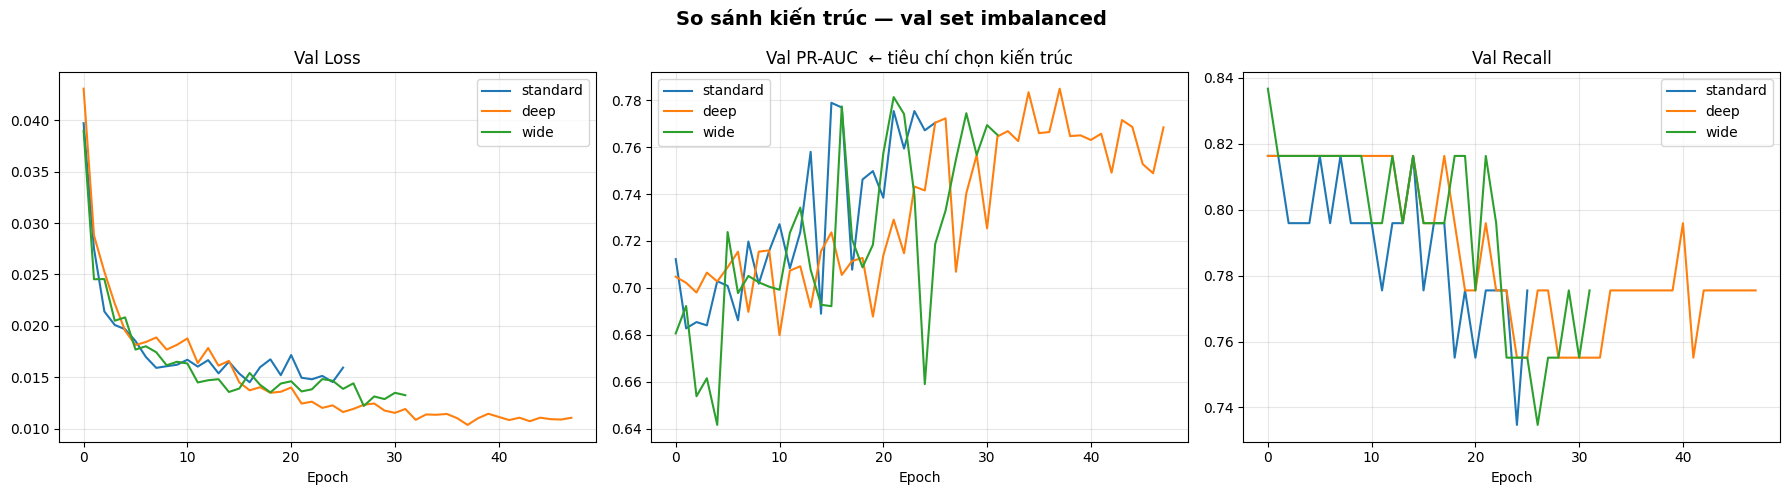

In [37]:
# Vẽ training curves để so sánh trực quan
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('So sánh kiến trúc — val set imbalanced ', fontsize=14, fontweight='bold')

colors  = ['tab:blue', 'tab:orange', 'tab:green']
metrics = [
    ('val_loss',   'Val Loss'),
    ('val_pr_auc', 'Val PR-AUC  ← tiêu chí chọn kiến trúc'),
    ('val_recall', 'Val Recall'),
]

for ax, (metric, title) in zip(axes, metrics):
    for (name, history_dict), color in zip(histories.items(), colors):
        if metric in history_dict:
            ax.plot(history_dict[metric], label=name, color=color)
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [38]:
# Bảng so sánh Tầng 1
print(f'MIN_PRECISION used for threshold selection: {MIN_PRECISION:.2f}')
print('\n--- Bảng so sánh kiến trúc (val set imbalanced) ---')
print(
    f"{'Kiến trúc':<12} {'Val ROC-AUC':>12} {'Val PR-AUC':>12} {'Threshold':>12} "
    f"{'Val Precision':>14} {'Val Recall':>11} {'Status':>24}"
)
print('-' * 100)

for result in sorted(selection_results, key=lambda x: -x['val_pr_auc']):
    threshold_info = result['threshold_info']
    threshold_text = (
        f"{threshold_info['threshold']:.4f}"
        if threshold_info['threshold'] is not None else 'None'
    )
    precision_text = (
        f"{threshold_info['precision']:.4f}"
        if not np.isnan(threshold_info['precision']) else 'nan'
    )
    recall_text = (
        f"{threshold_info['recall']:.4f}"
        if not np.isnan(threshold_info['recall']) else 'nan'
    )
    mark = '  <-- CHỌN' if result['architecture'] == best_arch else ''
    print(
        f"{result['architecture']:<12} {result['val_roc_auc']:>12.4f} "
        f"{result['val_pr_auc']:>12.4f} {threshold_text:>12} "
        f"{precision_text:>14} {recall_text:>11} "
        f"{threshold_info['selection_note']:>24}{mark}"
    )

print('\nSelected winner by validation metrics:')
print(f'- Winner architecture: {best_arch}')
print(f'- Model checkpoint   : {best_model_name}')
print(f'- Validation ROC-AUC : {winner["val_roc_auc"]:.4f}')
print(f'- Validation PR-AUC  : {winner["val_pr_auc"]:.4f}')
print(f'- Threshold status   : {best_threshold_info["selection_note"]}')
if best_threshold_info['threshold'] is not None:
    print(f'- Selected threshold : {best_threshold_info["threshold"]:.4f}')
else:
    print('- No feasible threshold satisfied the current MIN_PRECISION.')


MIN_PRECISION used for threshold selection: 0.60

--- Bảng so sánh kiến trúc (val set imbalanced) ---
Kiến trúc     Val ROC-AUC   Val PR-AUC    Threshold  Val Precision  Val Recall                   Status
----------------------------------------------------------------------------------------------------
wide               0.9368       0.7960       0.6122         0.6667      0.8163       feasible_threshold  <-- CHỌN
standard           0.9302       0.7893       0.2287         0.6667      0.8163       feasible_threshold
deep               0.9289       0.7881       0.0576         0.8000      0.8163       feasible_threshold

Selected winner by validation metrics:
- Winner architecture: wide
- Model checkpoint   : wide_mlp
- Validation ROC-AUC : 0.9368
- Validation PR-AUC  : 0.7960
- Threshold status   : feasible_threshold
- Selected threshold : 0.6122


## 6. TẦNG 2 — Đánh giá model tốt nhất trên test set

Kết quả `y_prob` được lưu vào `features/` .

In [39]:
# Load model tốt nhất từ file hoặc load lại xác suất đã cache
model_path = NN_BEST_MODEL_ALIAS
checkpoint_path = MODEL_DIR / f'best_{best_model_name}.keras'
best_model = None

if used_mlp_cache and NN_Y_PROB_PATH.exists():
    y_prob = np.load(NN_Y_PROB_PATH)
    print(f'Đã load cached probabilities: {NN_Y_PROB_PATH}')
else:
    if not model_path.exists():
        model_path = checkpoint_path
    if not model_path.exists():
        raise FileNotFoundError(f'Không tìm thấy model checkpoint để suy luận: {checkpoint_path}')

    best_model = keras.models.load_model(model_path)
    print(f'Đã load model: {model_path}')

    y_prob = best_model.predict(X_test, verbose=0).flatten()

if best_threshold_info['threshold'] is not None:
    y_pred = (y_prob >= best_threshold_info['threshold']).astype(int)
    print(f"Threshold applied on test: {best_threshold_info['threshold']:.4f}")
    print(f'Positive predictions on test: {int(y_pred.sum())}')
else:
    y_pred = None
    print('No feasible threshold found on validation, so threshold-based test metrics will be skipped.')

if best_threshold_info['threshold'] is not None:
    y_pred = (y_prob >= best_threshold_info['threshold']).astype(int)
    print(f"Threshold applied on test: {best_threshold_info['threshold']:.4f}")
    print(f'Positive predictions on test: {int(y_pred.sum())}')
else:
    y_pred = None
    print('No feasible threshold found on validation, so threshold-based test metrics will be skipped.')

print(f'y_prob shape : {y_prob.shape}')
print(f'y_prob range : [{y_prob.min():.4f}, {y_prob.max():.4f}]')
print(f'y_prob mean  : {y_prob.mean():.4f}')


Đã load model: ..\models\fraud_nn_best.keras
Threshold applied on test: 0.6122
Positive predictions on test: 123
y_prob shape : (56962,)
y_prob range : [0.0000, 1.0000]
y_prob mean  : 0.0023


In [40]:
# Lưu y_prob
np.save(NN_Y_PROB_PATH, y_prob)
print(f'Đã lưu: {NN_Y_PROB_PATH}')

# Lưu model winner dưới tên cố định để những lần chạy sau có thể load nhanh
if best_model is not None:
    best_model.save(NN_BEST_MODEL_ALIAS)
    best_model.save(MODEL_DIR / f'fraud_nn_{best_arch}.keras')
    print(f'Đã lưu model: {NN_BEST_MODEL_ALIAS}')
    print(f'Đã lưu model: {MODEL_DIR / f"fraud_nn_{best_arch}.keras"}')
else:
    print('Đang dùng cached probabilities; không cần lưu lại model.')

print(f'File      : {NN_Y_PROB_PATH}')
print(f'Model     : Neural Network ({best_arch})')
print(f'Val ROC-AUC: {winner["val_roc_auc"]:.4f}')
print(f'Val PR-AUC : {winner["val_pr_auc"]:.4f}')
print(f'Threshold : {best_threshold_info["threshold"]}')


Đã lưu: ..\features\nn_y_prob.npy
Đã lưu model: ..\models\fraud_nn_best.keras
Đã lưu model: ..\models\fraud_nn_wide.keras
File      : ..\features\nn_y_prob.npy
Model     : Neural Network (wide)
Val ROC-AUC: 0.9368
Val PR-AUC : 0.7960
Threshold : 0.6122468709945679


## 7. Đánh giá trên test set

In [41]:
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

test_metrics = {
    'Model': f'Neural Network ({best_arch})',
    'Validation ROC-AUC': winner['val_roc_auc'],
    'Validation PR-AUC': winner['val_pr_auc'],
    'Threshold Status': best_threshold_info['selection_note'],
    'Threshold': best_threshold_info['threshold'],
    'Test ROC-AUC': roc_auc_score(y_test, y_prob),
    'Test PR-AUC': average_precision_score(y_test, y_prob),
}

if y_pred is not None:
    cm = confusion_matrix(y_test, y_pred)
    test_metrics.update({
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-score': f1_score(y_test, y_pred, zero_division=0),
        'TP': int(cm[1, 1]),
        'FP': int(cm[0, 1]),
        'TN': int(cm[0, 0]),
        'FN': int(cm[1, 0]),
    })

print(pd.DataFrame([test_metrics]).to_string(index=False, float_format=lambda x: f'{x:.4f}'))

if y_pred is not None:
    print('\nClassification Report - Selected MLP architecture')
    print(classification_report(y_test, y_pred, target_names=['Non-Fraud', 'Fraud'], zero_division=0))

    print('Confusion Matrix - Selected MLP architecture')
    print(pd.DataFrame(
        confusion_matrix(y_test, y_pred),
        index=['Actual 0', 'Actual 1'],
        columns=['Pred 0', 'Pred 1'],
    ))
else:
    print('\nThreshold-based test metrics were skipped because validation did not find a feasible threshold.')


                Model  Validation ROC-AUC  Validation PR-AUC   Threshold Status  Threshold  Test ROC-AUC  Test PR-AUC  Accuracy  Precision  Recall  F1-score  TP  FP    TN  FN
Neural Network (wide)              0.9368             0.7960 feasible_threshold     0.6122        0.9784       0.8473    0.9990     0.6748  0.8469    0.7511  83  40 56824  15

Classification Report - Selected MLP architecture
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00     56864
       Fraud       0.67      0.85      0.75        98

    accuracy                           1.00     56962
   macro avg       0.84      0.92      0.88     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix - Selected MLP architecture
          Pred 0  Pred 1
Actual 0   56824      40
Actual 1      15      83


## 8. Visualization

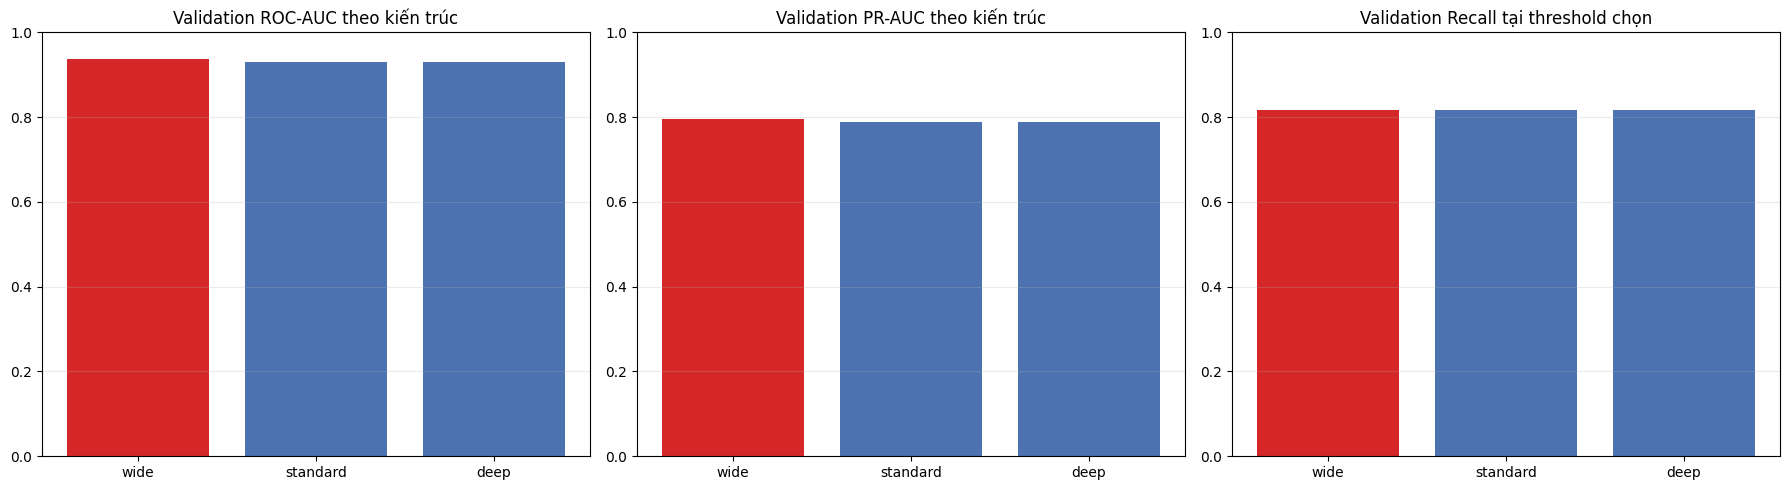

,Architecture,Val ROC-AUC,Val PR-AUC,Val Precision,Val Recall,Val F1
2,wide,0.936769,0.796001,0.666667,0.816327,0.733945
0,standard,0.930176,0.789312,0.666667,0.816327,0.733945
1,deep,0.928932,0.788053,0.800000,0.816327,0.808081


In [42]:
architecture_summary = pd.DataFrame([
    {
        'Architecture': result['architecture'],
        'Val ROC-AUC': result['val_roc_auc'],
        'Val PR-AUC': result['val_pr_auc'],
        'Val Precision': result['threshold_info']['precision'],
        'Val Recall': result['threshold_info']['recall'],
        'Val F1': result['threshold_info']['f1'],
    }
    for result in selection_results
]).sort_values('Val PR-AUC', ascending=False)

highlight_colors = [
    '#d62728' if arch == best_arch else '#4c72b0'
    for arch in architecture_summary['Architecture']
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_metrics = ['Val ROC-AUC', 'Val PR-AUC', 'Val Recall']
plot_titles = [
    'Validation ROC-AUC theo kiến trúc',
    'Validation PR-AUC theo kiến trúc',
    'Validation Recall tại threshold chọn',
]

for ax, metric, title in zip(axes, plot_metrics, plot_titles):
    ax.bar(architecture_summary['Architecture'], architecture_summary[metric], color=highlight_colors)
    ax.set_title(title)
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

display(architecture_summary)


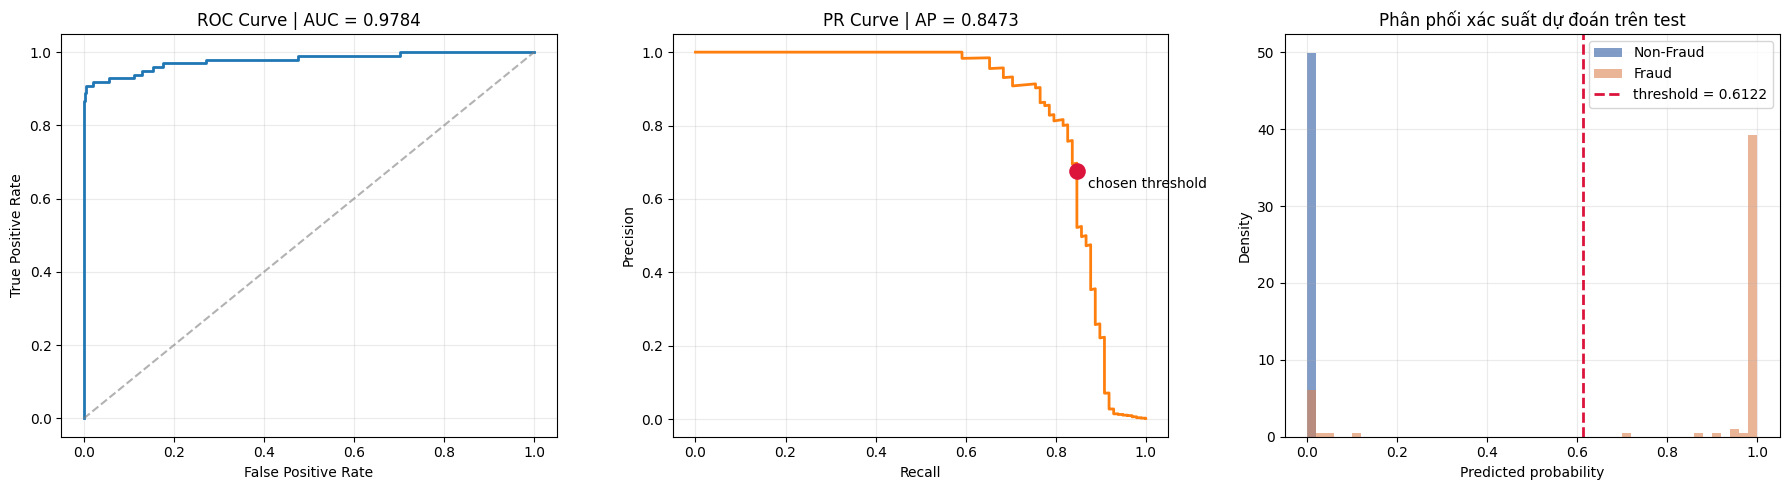

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fpr, tpr, _ = roc_curve(y_test, y_prob)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob)

axes[0].plot(fpr, tpr, color='#1f77b4', linewidth=2)
axes[0].plot([0, 1], [0, 1], '--', color='gray', alpha=0.6)
axes[0].set_title(f"ROC Curve | AUC = {roc_auc_score(y_test, y_prob):.4f}")
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].grid(alpha=0.25)

axes[1].plot(recall_curve, precision_curve, color='#ff7f0e', linewidth=2)
axes[1].set_title(f"PR Curve | AP = {average_precision_score(y_test, y_prob):.4f}")
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].grid(alpha=0.25)

if y_pred is not None:
    test_precision = precision_score(y_test, y_pred, zero_division=0)
    test_recall = recall_score(y_test, y_pred, zero_division=0)
    axes[1].scatter(test_recall, test_precision, color='crimson', s=120, zorder=5)
    axes[1].annotate('chosen threshold', (test_recall, test_precision), textcoords='offset points', xytext=(8, -12))

axes[2].hist(y_prob[y_test == 0], bins=50, alpha=0.70, color='#4c72b0', density=True, label='Non-Fraud')
axes[2].hist(y_prob[y_test == 1], bins=50, alpha=0.60, color='#dd8452', density=True, label='Fraud')
if best_threshold_info['threshold'] is not None:
    axes[2].axvline(best_threshold_info['threshold'], color='crimson', linestyle='--', linewidth=2, label=f"threshold = {best_threshold_info['threshold']:.4f}")
axes[2].set_title('Phân phối xác suất dự đoán trên test')
axes[2].set_xlabel('Predicted probability')
axes[2].set_ylabel('Density')
axes[2].legend()
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()
